In [10]:
import os
import random
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

from torchvision import transforms

import optuna

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    matthews_corrcoef,
    classification_report,
    confusion_matrix
)

import matplotlib.pyplot as plt

In [11]:
SEED = 42

IMAGE_SIZE = 224
NUM_CLASSES = 6

BATCH_SIZE = 32

NUM_TRIALS = 20
TRIAL_EPOCHS = 30
FINAL_EPOCHS = 50

CLASS_NAMES = [
    "MT_Blowhole",
    "MT_Break",
    "MT_Crack",
    "MT_Fray",
    "MT_Free",
    "MT_Uneven"
]

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

Device: cuda


In [12]:
random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [13]:
PROJECT_ROOT = Path.cwd().parent

DATASET_PATH = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "magnetic_tile"
)

print(DATASET_PATH)

d:\Study\industrial_visual_inspection\data\raw\magnetic_tile


In [ ]:
# Loading the images having jpg format only
image_paths = []
labels = []

for label, class_name in enumerate(CLASS_NAMES):

    image_folder = (
        DATASET_PATH
        / class_name
        / "Imgs"
    )

    paths = sorted(
        image_folder.glob("*.jpg")
    )

    print(
        f"{class_name}: {len(paths)} images"
    )

    image_paths.extend(paths)
    labels.extend(
        [label] * len(paths)
    )

MT_Blowhole: 115 images
MT_Break: 85 images
MT_Crack: 57 images
MT_Fray: 32 images
MT_Free: 952 images
MT_Uneven: 103 images


In [ ]:
# Train-Val-Test Split the data before transformations

train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    image_paths,
    labels,
    test_size=0.30,
    stratify=labels,
    random_state=SEED
)

val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths,
    temp_labels,
    test_size=0.50,
    stratify=temp_labels,
    random_state=SEED
)

print("Train:", len(train_paths))
print("Validation:", len(val_paths))
print("Test:", len(test_paths))

print("Train:")
print(Counter(train_labels))

print("\nValidation:")
print(Counter(val_labels))

print("\nTest:")
print(Counter(test_labels))

Train: 940
Validation: 202
Test: 202
Train:
Counter({4: 666, 0: 80, 5: 72, 1: 60, 2: 40, 3: 22})

Validation:
Counter({4: 143, 0: 17, 5: 16, 1: 13, 2: 8, 3: 5})

Test:
Counter({4: 143, 0: 18, 5: 15, 1: 12, 2: 9, 3: 5})


In [20]:
# Validation Transformations (No Augmentation)

val_test_transform = transforms.Compose([
    transforms.Resize(
        (IMAGE_SIZE, IMAGE_SIZE)
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.5],
        std=[0.5]
    )
])

In [21]:
# Training Transformations (Data Weighted Augmentation)

train_transform_C = transforms.Compose([

    transforms.Resize(
        (IMAGE_SIZE, IMAGE_SIZE)
    ),

    transforms.RandomHorizontalFlip(
        p=0.5
    ),

    transforms.RandomVerticalFlip(
        p=0.5
    ),

    transforms.RandomRotation(
        degrees=15
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.5],
        std=[0.5]
    )
])

In [22]:
# DataSet Class 
class MagneticTileDataset(Dataset):

    def __init__(
        self,
        image_paths,
        labels,
        transform=None
    ):

        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):

        return len(self.image_paths)

    def __getitem__(self, idx):

        image = Image.open(
            self.image_paths[idx]
        ).convert("L")

        label = self.labels[idx]

        if self.transform is not None:

            image = self.transform(image)

        return image, label

In [23]:
# Creating Train, Validation and Testing Datasets
train_dataset_C = MagneticTileDataset(
    train_paths,
    train_labels,
    transform=train_transform_C
)

val_dataset_C = MagneticTileDataset(
    val_paths,
    val_labels,
    transform=val_test_transform
)

test_dataset = MagneticTileDataset(
    test_paths,
    test_labels,
    transform=val_test_transform
)

In [25]:
# Creating a Balanced Sampler which samples images which have defects more than Normal Images
train_class_counts = Counter(
    train_labels
)

sample_weights = torch.tensor(
    [
        1.0 / train_class_counts[label]
        for label in train_labels
    ],
    dtype=torch.double
)

sampler_C = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(train_labels),
    replacement=True
)
print(
    "Training class counts:",
    train_class_counts
)

Training class counts: Counter({4: 666, 0: 80, 5: 72, 1: 60, 2: 40, 3: 22})


In [26]:
# Verify Balanced Sampling
sampled_labels = []

for _ in range(1):

    for _, labels_batch in DataLoader(
        train_dataset_C,
        batch_size=32,
        sampler=sampler_C,
        num_workers=0
    ):

        sampled_labels.extend(
            labels_batch.tolist()
        )

print(
    Counter(sampled_labels)
)

Counter({0: 171, 2: 162, 1: 158, 3: 158, 5: 149, 4: 142})


In [28]:
# Model CNN (Having 1.2Million Trainable Parameters) same we used in Experiment C in previous notebook
class ComplexCNN(nn.Module):

    def __init__(self, num_classes=6,
        dropout1=0.0,
        dropout2=0.0):
        
        super().__init__()

        self.features = nn.Sequential(

        # Block 1
        nn.Conv2d(1, 32, 3, padding=1),
        nn.BatchNorm2d(32),
        nn.ReLU(),

        nn.Conv2d(32, 32, 3, padding=1),
        nn.BatchNorm2d(32),
        nn.ReLU(),

        nn.MaxPool2d(kernel_size=2, stride=2),

        # Block 2
        nn.Conv2d(32, 64, 3, padding=1),
        nn.BatchNorm2d(64),
        nn.ReLU(),

        nn.Conv2d(64, 64, 3, padding=1),
        nn.BatchNorm2d(64),
        nn.ReLU(),

        nn.MaxPool2d(kernel_size=2, stride=2),

        # Block 3
        nn.Conv2d(64, 128, 3, padding=1),
        nn.BatchNorm2d(128),
        nn.ReLU(),

        nn.Conv2d(128, 128, 3, padding=1),
        nn.BatchNorm2d(128),
        nn.ReLU(),

        nn.MaxPool2d(kernel_size=2, stride=2),

        # Block 4
        nn.Conv2d(128, 256, 3, padding=1),
        nn.BatchNorm2d(256),
        nn.ReLU(),

        nn.Conv2d(256, 256, 3, padding=1),
        nn.BatchNorm2d(256),
        nn.ReLU(),

        nn.MaxPool2d(kernel_size=2, stride=2)
    )

        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(dropout1),

            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(dropout2),

            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model = ComplexCNN().to(device)

total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(
    f"Total parameters: {total_params:,}"
)

print(
    f"Trainable parameters: {trainable_params:,}"
)

Total parameters: 1,215,526
Trainable parameters: 1,215,526


In [29]:
# Macro F1 Function

def get_macro_f1(
    model,
    loader,
    device
):

    model.eval()

    all_labels = []
    all_predictions = []

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)

            outputs = model(images)

            predictions = (
                outputs
                .argmax(dim=1)
                .cpu()
            )

            all_predictions.extend(
                predictions.numpy()
            )

            all_labels.extend(
                labels.numpy()
            )

    return f1_score(
        all_labels,
        all_predictions,
        average="macro",
        zero_division=0
    )

### Optuna Objective

In [30]:
def objective(trial):

    # -------------------------
    # Hyperparameters
    # -------------------------

    learning_rate = trial.suggest_float(
        "learning_rate",
        1e-4,
        3e-3,
        log=True
    )

    weight_decay = trial.suggest_float(
        "weight_decay",
        1e-6,
        1e-3,
        log=True
    )

    dropout1 = trial.suggest_float(
        "dropout1",
        0.0,
        0.4
    )

    dropout2 = trial.suggest_float(
        "dropout2",
        0.0,
        0.4
    )


    batch_size = trial.suggest_categorical(
        "batch_size",
        [16, 32, 64]
    )

    optimizer_name = trial.suggest_categorical(
        "optimizer",
        ["Adam", "AdamW", "SGD"]
    )

    # -------------------------
    # DataLoaders
    # -------------------------

    train_loader = DataLoader(
        train_dataset_C,
        batch_size=batch_size,
        sampler=sampler_C,
        num_workers=0,
        pin_memory=False
    )

    val_loader = DataLoader(
        val_dataset_C,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0,
        pin_memory=False
    )

    # -------------------------
    # Fresh model
    # -------------------------

    model = ComplexCNN(
        num_classes=NUM_CLASSES,
        dropout1=dropout1,
        dropout2=dropout2
    ).to(device)

    criterion = nn.CrossEntropyLoss()

    # -------------------------
    # Optimizer
    # -------------------------

    if optimizer_name == "Adam":

        optimizer = torch.optim.Adam(
            model.parameters(),
            lr=learning_rate,
            weight_decay=weight_decay
        )

    elif optimizer_name == "AdamW":

        optimizer = torch.optim.AdamW(
            model.parameters(),
            lr=learning_rate,
            weight_decay=weight_decay
        )

    else:

        optimizer = torch.optim.SGD(
            model.parameters(),
            lr=learning_rate,
            momentum=trial.suggest_float("momentum", 0.8, 0.99), # Using SGD with Momentum
            weight_decay=weight_decay
        )

    best_macro_f1 = 0.0

    # -------------------------
    # Trial training
    # -------------------------

    for epoch in range(TRIAL_EPOCHS):

        model.train()

        for images, labels in train_loader:

            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)

            loss = criterion(
                outputs,
                labels
            )

            loss.backward()

            optimizer.step()

        # -------------------------
        # Validation
        # -------------------------

        macro_f1 = get_macro_f1(
            model,
            val_loader,
            device
        )

        best_macro_f1 = max(
            best_macro_f1,
            macro_f1
        )

        # Send result to Optuna
        trial.report(
            macro_f1,
            epoch
        )

        # Stop poor trials
        if trial.should_prune():

            raise optuna.exceptions.TrialPruned()

    return best_macro_f1

In [31]:
## Creating Study

study = optuna.create_study(
    direction="maximize",
    study_name="VisionInspect_ComplexCNN",
    pruner=optuna.pruners.MedianPruner(
        n_startup_trials=5,
        n_warmup_steps=5
    )
)

[I 2026-08-08 20:15:57,607] A new study created in memory with name: VisionInspect_ComplexCNN


In [32]:
study.optimize(
    objective,
    n_trials=NUM_TRIALS,
    show_progress_bar=True
)

  0%|          | 0/20 [00:00<?, ?it/s]

[I 2026-08-08 20:34:32,170] Trial 0 finished with value: 0.23103352402500874 and parameters: {'learning_rate': 0.000855305204121515, 'weight_decay': 4.3643904778224065e-06, 'dropout1': 0.2969736021470728, 'dropout2': 0.13504559993483492, 'batch_size': 64, 'optimizer': 'SGD', 'momentum': 0.909887230383286}. Best is trial 0 with value: 0.23103352402500874.
[I 2026-08-08 20:50:27,108] Trial 1 finished with value: 0.4957285844869728 and parameters: {'learning_rate': 0.00011292027593556868, 'weight_decay': 0.0003596017949659193, 'dropout1': 0.18504221856416897, 'dropout2': 0.12213771320072891, 'batch_size': 16, 'optimizer': 'AdamW'}. Best is trial 1 with value: 0.4957285844869728.
[I 2026-08-08 21:07:35,487] Trial 2 finished with value: 0.2747662477270981 and parameters: {'learning_rate': 0.00048455379215184426, 'weight_decay': 2.156633355279708e-06, 'dropout1': 0.20315540833002743, 'dropout2': 0.34478168123334013, 'batch_size': 64, 'optimizer': 'Adam'}. Best is trial 1 with value: 0.495728

In [33]:
# Best Hyperparameters

print(
    "Best Validation Macro F1:",
    study.best_value
)

print("\nBest Hyperparameters:")

for key, value in study.best_params.items():

    print(
        f"{key}: {value}"
    )

Best Validation Macro F1: 0.6752144648055598

Best Hyperparameters:
learning_rate: 0.00010880349762691581
weight_decay: 0.00095736658307158
dropout1: 0.020551953464775563
dropout2: 0.007046586457583351
batch_size: 16
optimizer: AdamW


In [36]:
# Trial Result

trials_df = study.trials_dataframe()

trials_df[
    [
        "number",
        "value",
        "state",
        "params_learning_rate",
        "params_weight_decay",
        "params_dropout1",
        "params_dropout2",
        "params_batch_size",
        "params_optimizer"
    ]
].sort_values(
    "value",
    ascending=False
).head(10)

,number,value,state,params_learning_rate,params_weight_decay,params_dropout1,params_dropout2,params_batch_size,params_optimizer
11,11,0.675214,COMPLETE,0.000109,0.000957,0.020552,0.007047,16,AdamW
12,12,0.658437,COMPLETE,0.000100,0.000999,0.000415,0.002961,16,AdamW
13,13,0.635500,COMPLETE,0.000150,0.000914,0.016904,0.001335,16,AdamW
15,15,0.607531,COMPLETE,0.000205,0.000450,0.088015,0.052859,32,AdamW
14,14,0.601102,COMPLETE,0.000187,0.000032,0.073934,0.058175,16,AdamW
10,10,0.515139,COMPLETE,0.000113,0.000985,0.010436,0.005653,16,AdamW
1,1,0.495729,COMPLETE,0.000113,0.000360,0.185042,0.122138,16,AdamW
3,3,0.331336,COMPLETE,0.000336,0.000173,0.221782,0.126239,16,SGD
4,4,0.330277,COMPLETE,0.000332,0.000174,0.390080,0.362084,16,AdamW
2,2,0.274766,COMPLETE,0.000485,0.000002,0.203155,0.344782,64,Adam


In [ ]:
# ! pip install plotly


   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   ------ --------------------------------- 1.6/9.9 MB 12.4 MB/s eta 0:00:01
   ---------------------------------------- 9.9/9.9 MB 29.7 MB/s  0:00:00


In [44]:
# Best Parameters

best_params = study.best_params

print(best_params)

{'learning_rate': 0.00010880349762691581, 'weight_decay': 0.00095736658307158, 'dropout1': 0.020551953464775563, 'dropout2': 0.007046586457583351, 'batch_size': 16, 'optimizer': 'AdamW'}


### Creating a Fresh Model With Best Parameters

In [45]:
final_model = ComplexCNN(
    num_classes=NUM_CLASSES,
    dropout1=best_params["dropout1"],
    dropout2=best_params["dropout2"]
).to(device)

In [47]:
# Final Optimizer
if best_params["optimizer"] == "Adam":

    final_optimizer = torch.optim.Adam(
        final_model.parameters(),
        lr=best_params["learning_rate"],
        weight_decay=best_params["weight_decay"]
    )

elif best_params["optimizer"] == "AdamW":

    final_optimizer = torch.optim.AdamW(
        final_model.parameters(),
        lr=best_params["learning_rate"],
        weight_decay=best_params["weight_decay"]
    )

else:

    final_optimizer = torch.optim.sgd(
            final_model.parameters(),
            lr=best_params["learning_rate"],
            momentum = best_params["momentum"],
            weight_decay=best_params["weight_decay"]
        )

In [48]:
# Final DataLoaders
final_train_loader = DataLoader(
    train_dataset_C,
    batch_size=best_params["batch_size"],
    sampler=sampler_C,
    num_workers=0,
    pin_memory=False
)

final_val_loader = DataLoader(
    val_dataset_C,
    batch_size=best_params["batch_size"],
    shuffle=False,
    num_workers=0,
    pin_memory=False
)

final_test_loader = DataLoader(
    test_dataset,
    batch_size=best_params["batch_size"],
    shuffle=False,
    num_workers=0,
    pin_memory=False
)

In [49]:
# Final Training 
def train_final_model(
    model,
    train_loader,
    val_loader,
    optimizer,
    device,
    epochs=50,
    save_path="best_optuna_cnn.pth"
):

    criterion = nn.CrossEntropyLoss()

    best_macro_f1 = -1

    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": [],
        "val_macro_f1": []
    }

    for epoch in range(epochs):

        # =========================
        # Training
        # =========================

        model.train()

        running_loss = 0.0
        correct = 0
        total = 0

        for images, labels in train_loader:

            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)

            loss = criterion(
                outputs,
                labels
            )

            loss.backward()

            optimizer.step()

            running_loss += (
                loss.item()
                * images.size(0)
            )

            predictions = outputs.argmax(
                dim=1
            )

            correct += (
                predictions == labels
            ).sum().item()

            total += labels.size(0)

        train_loss = (
            running_loss / total
        )

        train_acc = (
            correct / total
        )

        # =========================
        # Validation
        # =========================

        model.eval()

        val_running_loss = 0.0
        val_correct = 0
        val_total = 0

        all_labels = []
        all_predictions = []

        with torch.no_grad():

            for images, labels in val_loader:

                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)

                loss = criterion(
                    outputs,
                    labels
                )

                val_running_loss += (
                    loss.item()
                    * images.size(0)
                )

                predictions = outputs.argmax(
                    dim=1
                )

                val_correct += (
                    predictions == labels
                ).sum().item()

                val_total += labels.size(0)

                all_labels.extend(
                    labels.cpu().numpy()
                )

                all_predictions.extend(
                    predictions.cpu().numpy()
                )

        val_loss = (
            val_running_loss
            / val_total
        )

        val_acc = (
            val_correct
            / val_total
        )

        val_macro_f1 = f1_score(
            all_labels,
            all_predictions,
            average="macro",
            zero_division=0
        )

        # =========================
        # Store history
        # =========================

        history["train_loss"].append(
            train_loss
        )

        history["train_acc"].append(
            train_acc
        )

        history["val_loss"].append(
            val_loss
        )

        history["val_acc"].append(
            val_acc
        )

        history["val_macro_f1"].append(
            val_macro_f1
        )

        print(
            f"Epoch [{epoch+1}/{epochs}] | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Acc: {val_acc:.4f} | "
            f"Val Macro F1: {val_macro_f1:.4f}"
        )

        # =========================
        # Best checkpoint
        # =========================

        if val_macro_f1 > best_macro_f1:

            best_macro_f1 = val_macro_f1

            torch.save(
                model.state_dict(),
                save_path
            )

    print(
        f"\nBest Validation Macro F1: "
        f"{best_macro_f1:.4f}"
    )

    return history

In [50]:
# Train Fine-Tuned CNN

history_optuna = train_final_model(
    model=final_model,
    train_loader=final_train_loader,
    val_loader=final_val_loader,
    optimizer=final_optimizer,
    device=device,
    epochs=FINAL_EPOCHS,
    save_path="best_optuna_complex_cnn.pth"
)

Epoch [1/50] | Train Loss: 1.7370 | Train Acc: 0.2649 | Val Loss: 1.9444 | Val Acc: 0.0743 | Val Macro F1: 0.1018
Epoch [2/50] | Train Loss: 1.6626 | Train Acc: 0.3245 | Val Loss: 1.8282 | Val Acc: 0.1089 | Val Macro F1: 0.0721
Epoch [3/50] | Train Loss: 1.6426 | Train Acc: 0.3202 | Val Loss: 2.0609 | Val Acc: 0.0644 | Val Macro F1: 0.0751
Epoch [4/50] | Train Loss: 1.5759 | Train Acc: 0.3777 | Val Loss: 1.9568 | Val Acc: 0.0891 | Val Macro F1: 0.0923
Epoch [5/50] | Train Loss: 1.5421 | Train Acc: 0.3947 | Val Loss: 1.8162 | Val Acc: 0.1386 | Val Macro F1: 0.1465
Epoch [6/50] | Train Loss: 1.5083 | Train Acc: 0.4160 | Val Loss: 1.7346 | Val Acc: 0.1436 | Val Macro F1: 0.1309
Epoch [7/50] | Train Loss: 1.4973 | Train Acc: 0.4011 | Val Loss: 1.8509 | Val Acc: 0.1238 | Val Macro F1: 0.1572
Epoch [8/50] | Train Loss: 1.4072 | Train Acc: 0.4564 | Val Loss: 1.8921 | Val Acc: 0.0842 | Val Macro F1: 0.0888
Epoch [9/50] | Train Loss: 1.3671 | Train Acc: 0.4968 | Val Loss: 1.8565 | Val Acc: 0.13

In [51]:
# Load the Best Model

final_model.load_state_dict(
    torch.load(
        "best_optuna_complex_cnn.pth",
        map_location=device
    )
)

final_model.to(device)

ComplexCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (9): ReLU()
    (10): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (12): ReLU()
    (13): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (14): Conv2d(64, 128, k

In [52]:
# Test Predictions

final_model.eval()

all_test_labels = []
all_test_predictions = []

with torch.no_grad():

    for images, labels in final_test_loader:

        images = images.to(device)

        outputs = final_model(images)

        predictions = (
            outputs
            .argmax(dim=1)
            .cpu()
        )

        all_test_predictions.extend(
            predictions.numpy()
        )

        all_test_labels.extend(
            labels.numpy()
        )

all_test_labels = np.array(
    all_test_labels
)

all_test_predictions = np.array(
    all_test_predictions
)

In [53]:
# Final Metrics

accuracy = accuracy_score(
    all_test_labels,
    all_test_predictions
)

balanced_accuracy = balanced_accuracy_score(
    all_test_labels,
    all_test_predictions
)

macro_f1 = f1_score(
    all_test_labels,
    all_test_predictions,
    average="macro",
    zero_division=0
)

mcc = matthews_corrcoef(
    all_test_labels,
    all_test_predictions
)

print(
    f"Accuracy:          {accuracy:.4f}"
)

print(
    f"Balanced Accuracy: {balanced_accuracy:.4f}"
)

print(
    f"Macro F1:          {macro_f1:.4f}"
)

print(
    f"MCC:               {mcc:.4f}"
)

Accuracy:          0.8911
Balanced Accuracy: 0.6951
Macro F1:          0.7268
MCC:               0.7647


In [54]:
# Classification Report

print(
    classification_report(
        all_test_labels,
        all_test_predictions,
        target_names=CLASS_NAMES,
        zero_division=0
    )
)

# Confusion Matrix

cm = confusion_matrix(
    all_test_labels,
    all_test_predictions
)

print(cm)



              precision    recall  f1-score   support

 MT_Blowhole       0.84      0.89      0.86        18
    MT_Break       1.00      0.25      0.40        12
    MT_Crack       1.00      0.67      0.80         9
     MT_Fray       0.67      0.40      0.50         5
     MT_Free       0.91      0.97      0.94       143
   MT_Uneven       0.75      1.00      0.86        15

    accuracy                           0.89       202
   macro avg       0.86      0.70      0.73       202
weighted avg       0.90      0.89      0.88       202

[[ 16   0   0   0   1   1]
 [  2   3   0   0   7   0]
 [  0   0   6   0   2   1]
 [  0   0   0   2   3   0]
 [  1   0   0   1 138   3]
 [  0   0   0   0   0  15]]


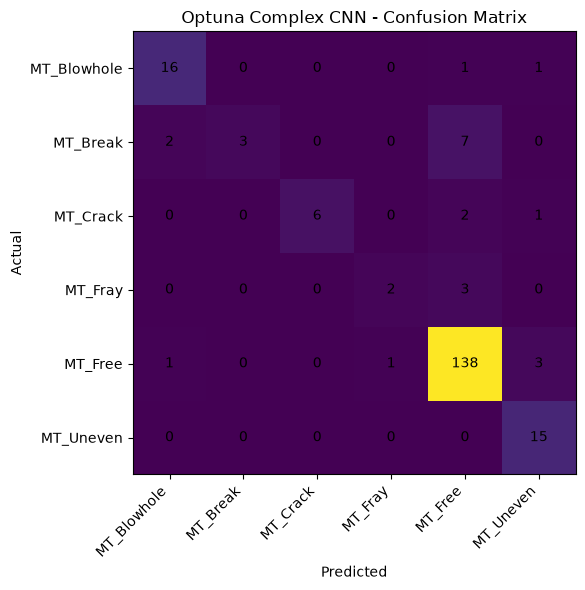

In [55]:
# Visualizer

plt.figure(figsize=(8, 6))

plt.imshow(cm)

plt.xticks(
    range(NUM_CLASSES),
    CLASS_NAMES,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(NUM_CLASSES),
    CLASS_NAMES
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title(
    "Optuna Complex CNN - Confusion Matrix"
)

for i in range(NUM_CLASSES):

    for j in range(NUM_CLASSES):

        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.tight_layout()

plt.show()

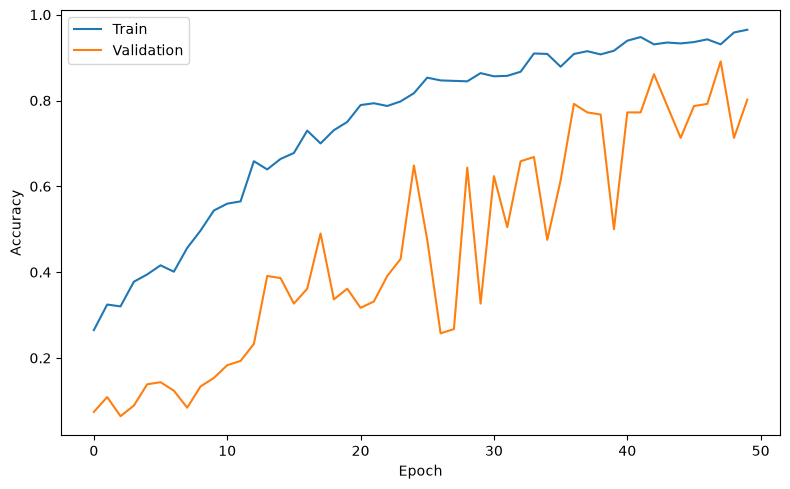

In [56]:
# Accuracy
plt.figure(figsize=(8, 5))

plt.plot(
    history_optuna["train_acc"],
    label="Train"
)

plt.plot(
    history_optuna["val_acc"],
    label="Validation"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()

plt.tight_layout()

plt.show()

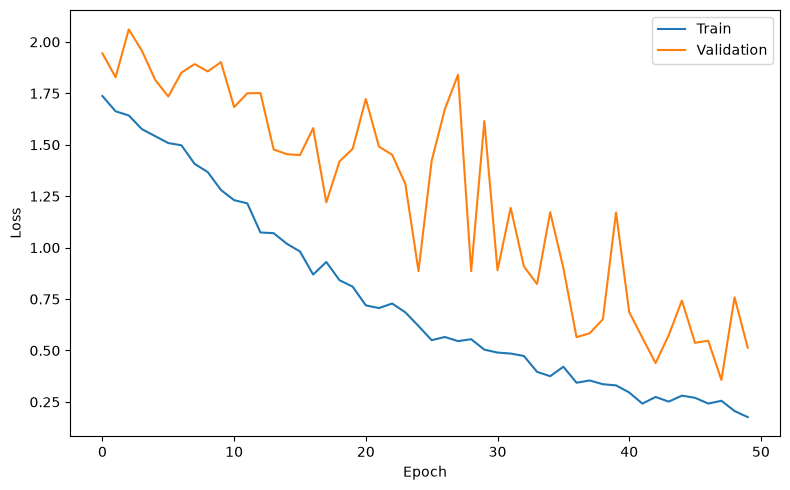

In [57]:
# Loss

plt.figure(figsize=(8, 5))

plt.plot(
    history_optuna["train_loss"],
    label="Train"
)

plt.plot(
    history_optuna["val_loss"],
    label="Validation"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()

plt.tight_layout()

plt.show()

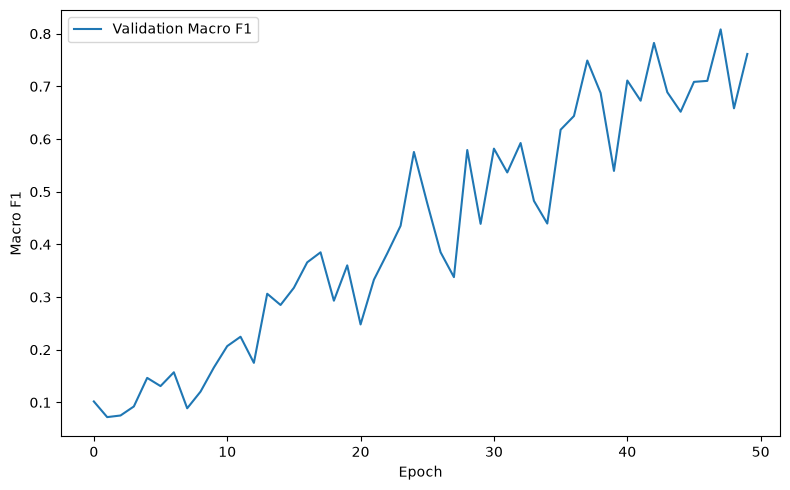

In [58]:
# Macro F1
plt.figure(figsize=(8, 5))

plt.plot(
    history_optuna["val_macro_f1"],
    label="Validation Macro F1"
)

plt.xlabel("Epoch")
plt.ylabel("Macro F1")

plt.legend()

plt.tight_layout()

plt.show()

In [59]:
# Save Results
os.makedirs(
    "outputs",
    exist_ok=True
)

results = {
    "model": "ComplexCNN_Optuna",
    "accuracy": accuracy,
    "balanced_accuracy": balanced_accuracy,
    "macro_f1": macro_f1,
    "mcc": mcc,
    "best_validation_macro_f1": study.best_value,
    **best_params
}

results_df = pd.DataFrame(
    [results]
)

results_df

results_df.to_csv(
    "outputs/optuna_cnn_results.csv",
    index=False
)

study.trials_dataframe().to_csv(
    "outputs/optuna_trials.csv",
    index=False
)

Optuna hyperparameter tuning produced a substantially improved custom CNN configuration with approximately 1.2M trainable parameters. On the held-out test set, the model achieved 89.11% accuracy, 69.51% balanced accuracy, 72.68% macro F1, and an MCC of 0.765. Compared with the previous 7M-parameter CNN, the tuned model achieved stronger overall and class-balanced performance while using considerably fewer parameters. The confusion matrix shows strong recognition of MT_Blowhole, MT_Crack, MT_Free, and MT_Uneven, while MT_Break remains the primary classification challenge. Although the training curves indicate continued overfitting, the tuned model demonstrates substantially better generalization than the previous custom CNN. This establishes the Optuna-tuned CNN as the strongest custom-CNN baseline before proceeding to transfer learning.